In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
# (Importa aquí tus clases de modelos y funciones del Notebook 05)

# Rutas a tus pesos entrenados (ajusta si es necesario)
paths = {
    "XceptionNet": r"C:\TFG\modelos\best_xception_loss.pth",
    "EfficientNet-B3": r"C:\TFG\modelos\best_effnet_loss.pth",
    "MesoInception-4": r"C:\TFG\modelos\best_mesoinception_mejorado_loss.pth",
    "ViT": r"C:\TFG\modelos\best_vit_loss.pth"
}

# Configuración de Transformaciones Individuales
transforms_dict = {
    "XceptionNet": transforms.Compose([
        transforms.Resize((299, 299)), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "EfficientNet-B3": transforms.Compose([
        transforms.Resize((300, 300)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "MesoInception-4": transforms.Compose([
        transforms.Resize((256, 256)), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "ViT": transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
}

In [4]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, log_loss, roc_auc_score, 
                             matthews_corrcoef, confusion_matrix)
import timm

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y DISPOSITIVO
# ==========================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATH_C40 = r'C:\TFG\Dataset_C40_Procesado\test'

# Rutas a tus pesos (.pth) entrenados con C23
MODEL_PATHS = {
    "XceptionNet": r"C:\TFG\modelos\best_xception_loss.pth",
    "EfficientNet-B3": r"C:\TFG\modelos\best_effnet_loss.pth",
    "MesoInception-4": r"C:\TFG\modelos\best_mesoinception_mejorado_loss.pth",
    "ViT": r"C:\TFG\modelos\best_vit_loss.pth"
}

print(f"🔥 Evaluando en: {DEVICE}")

# ==========================================
# 2. CLASE DATASET (LECTURA DE CARPETAS)
# ==========================================
class DeepfakeDatasetC40(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        
        for label in ['real', 'fake']:
            folder = os.path.join(root_dir, label)
            if os.path.exists(folder):
                for img in os.listdir(folder):
                    if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((os.path.join(folder, img), 0 if label == 'real' else 1))
        
        if len(self.samples) == 0:
            raise RuntimeError(f"No se encontraron imágenes en {root_dir}")
            
    def __len__(self): return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# ==========================================
# 3. DEFINICIÓN DE MESOINCEPTION-4
# ==========================================
class MesoInception4(nn.Module):
    def __init__(self, num_classes=2):
        super(MesoInception4, self).__init__()
        self.inception1 = self._inception_layer(3, 8, 8, 8, 8)
        self.inception2 = self._inception_layer(32, 8, 16, 16, 8)
        self.conv3 = nn.Conv2d(48, 64, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.maxpool2 = nn.MaxPool2d(kernel_size=4, stride=4)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def _inception_layer(self, in_channels, out1, out2, out3, out4):
        conv1 = nn.Sequential(nn.Conv2d(in_channels, out1, kernel_size=1, padding=0), nn.BatchNorm2d(out1), nn.ReLU())
        conv2 = nn.Sequential(nn.Conv2d(in_channels, out2, kernel_size=3, padding=1), nn.BatchNorm2d(out2), nn.ReLU())
        conv3 = nn.Sequential(nn.Conv2d(in_channels, out3, kernel_size=5, padding=2), nn.BatchNorm2d(out3), nn.ReLU())
        conv4 = nn.Sequential(nn.Conv2d(in_channels, out4, kernel_size=7, padding=3), nn.BatchNorm2d(out4), nn.ReLU())
        return nn.ModuleList([conv1, conv2, conv3, conv4])

    def forward(self, x):
        x = torch.cat([layer(x) for layer in self.inception1], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = torch.cat([layer(x) for layer in self.inception2], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = self.relu(self.bn1(self.conv3(x)))
        x = self.maxpool1(x)
        x = self.relu(self.bn2(self.conv4(x)))
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# ==========================================
# 4. FUNCIONES AUXILIARES DE MÉTRICAS
# ==========================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate_all_metrics(name, y_true, y_prob, time_ms, params):
    y_pred = (y_prob > 0.5).astype(int)
    return {
        "Modelo": name,
        "Acc": accuracy_score(y_true, y_pred),
        "Prec": precision_score(y_true, y_pred, zero_division=0),
        "Rec": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_prob),
        "Loss": log_loss(y_true, y_prob, labels=[0, 1]),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Time_ms": time_ms,
        "Params": params
    }

def run_inference(model, test_loader, model_name):
    model.eval()
    model.to(DEVICE)
    y_true, y_prob = [], []
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"🔍 Inferencia {model_name}"):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            
            # Obtener probabilidad de clase 1 (Fake)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            
            y_prob.extend(probs)
            y_true.extend(labels.numpy())
            
    total_time = (time.time() - start_time)
    time_per_image_ms = (total_time / len(y_true)) * 1000 
    return np.array(y_true), np.array(y_prob), time_per_image_ms

# ==========================================
# 5. BUCLE PRINCIPAL DE EVALUACIÓN
# ==========================================
if __name__ == "__main__":
    resultados = []

    # Diccionario de transformaciones específicas
    transforms_dict = {
        "XceptionNet": transforms.Compose([
            transforms.Resize((299, 299)), transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ]),
        "EfficientNet-B3": transforms.Compose([
            transforms.Resize((300, 300)), transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        "MesoInception-4": transforms.Compose([
            transforms.Resize((256, 256)), transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ]),
        "ViT": transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])
    }

    for nombre, path in MODEL_PATHS.items():
        print(f"\n🚀 Preparando evaluación de: {nombre}")
        
        try:
            # 1. Instanciar arquitectura
            if nombre == "XceptionNet":
                model = timm.create_model('xception', pretrained=False, num_classes=2)
            elif nombre == "EfficientNet-B3":
                model = timm.create_model('tf_efficientnet_b3', pretrained=False, num_classes=2)
            elif nombre == "MesoInception-4":
                model = MesoInception4(num_classes=2)
            elif nombre == "ViT":
                model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)

            # 2. Cargar pesos
            model.load_state_dict(torch.load(path, map_location=DEVICE))
            
            # 3. Preparar DataLoader con su transformación específica
            dataset = DeepfakeDatasetC40(PATH_C40, transform=transforms_dict[nombre])
            loader = DataLoader(dataset, batch_size=32, shuffle=False)

            # 4. Inferencia
            y_true, y_prob, t_ms = run_inference(model, loader, nombre)
            
            # 5. Calcular métricas
            metricas = evaluate_all_metrics(nombre, y_true, y_prob, t_ms, count_parameters(model))
            resultados.append(metricas)
            
        except Exception as e:
            print(f"❌ Error evaluando {nombre}: {e}")

    # ==========================================
    # 6. TABLA FINAL DE RESULTADOS
    # ==========================================
    df_final = pd.DataFrame(resultados)
    print("\n" + "="*80)
    print("📊 RESULTADOS FINALES SOBRE DATASET C40 (BAJA CALIDAD)")
    print("="*80)
    print(df_final[['Modelo', 'Acc', 'AUC', 'Loss', 'MCC', 'Time_ms']].to_string(index=False))
    print("="*80)
    
    # Opcional: Guardar a CSV para tu TFG
    # df_final.to_csv("Resultados_Comparativa_C40.csv", index=False)

🔥 Evaluando en: cuda

🚀 Preparando evaluación de: XceptionNet


C:\Users\User\AppData\Local\Temp\ipykernel_17752\3722002822.py:185: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE)


🚀 Preparando evaluación de: EfficientNet-B3


🔍 Inferencia EfficientNet-B3: 100%|██████████| 188/188 [00:39<00:00,  4.73it/s]
C:\Users\User\AppData\Local\Temp\ipykernel_17752\3722002822.py:185: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exp


🚀 Preparando evaluación de: MesoInception-4


🔍 Inferencia MesoInception-4: 100%|██████████| 188/188 [00:20<00:00,  9.18it/s]



🚀 Preparando evaluación de: ViT


C:\Users\User\AppData\Local\Temp\ipykernel_17752\3722002822.py:185: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE)


📊 RESULTADOS FINALES SOBRE DATASET C40 (BAJA CALIDAD)
         Modelo      Acc      AUC     Loss      MCC  Time_ms
    XceptionNet 0.584431 0.620917 0.966204 0.169473 8.028700
EfficientNet-B3 0.603767 0.650678 0.818722 0.216038 6.619118
MesoInception-4 0.609268 0.662080 0.655711 0.218562 3.414040
            ViT 0.654609 0.707954 0.809937 0.310605 8.812705


# MÉTRICAS

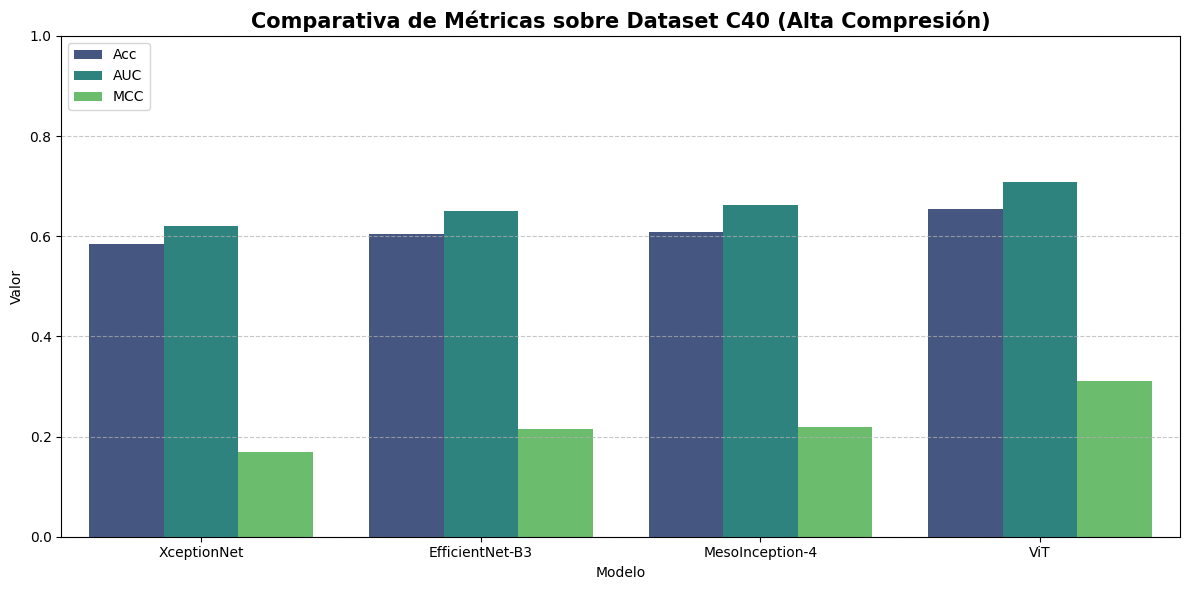

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_final[['Modelo', 'Acc', 'AUC', 'MCC']].copy()
df_melted = df_plot.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')  # ← df_plot, no df_metrics

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Modelo', y='Valor', hue='Métrica', palette='viridis')

plt.title('Comparativa de Métricas sobre Dataset C40 (Alta Compresión)', fontsize=15, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


🚀 Evaluando XceptionNet...


c:\TFG\venv_tfg\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
C:\Users\User\AppData\Local\Temp\ipykernel_17752\3863761076.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of

✅ Matriz de XceptionNet generada correctamente.

🚀 Evaluando EfficientNet-B3...


C:\Users\User\AppData\Local\Temp\ipykernel_17752\3863761076.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_eval.load_state_dict(torch.load(path, map_location=DEV

✅ Matriz de EfficientNet-B3 generada correctamente.

🚀 Evaluando MesoInception-4...


🔍 MesoInception-4: 100%|██████████| 188/188 [00:20<00:00,  9.11it/s]


✅ Matriz de MesoInception-4 generada correctamente.

🚀 Evaluando ViT...


C:\Users\User\AppData\Local\Temp\ipykernel_17752\3863761076.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_eval.load_state_dict(torch.load(path, map_location=DEV

✅ Matriz de ViT generada correctamente.


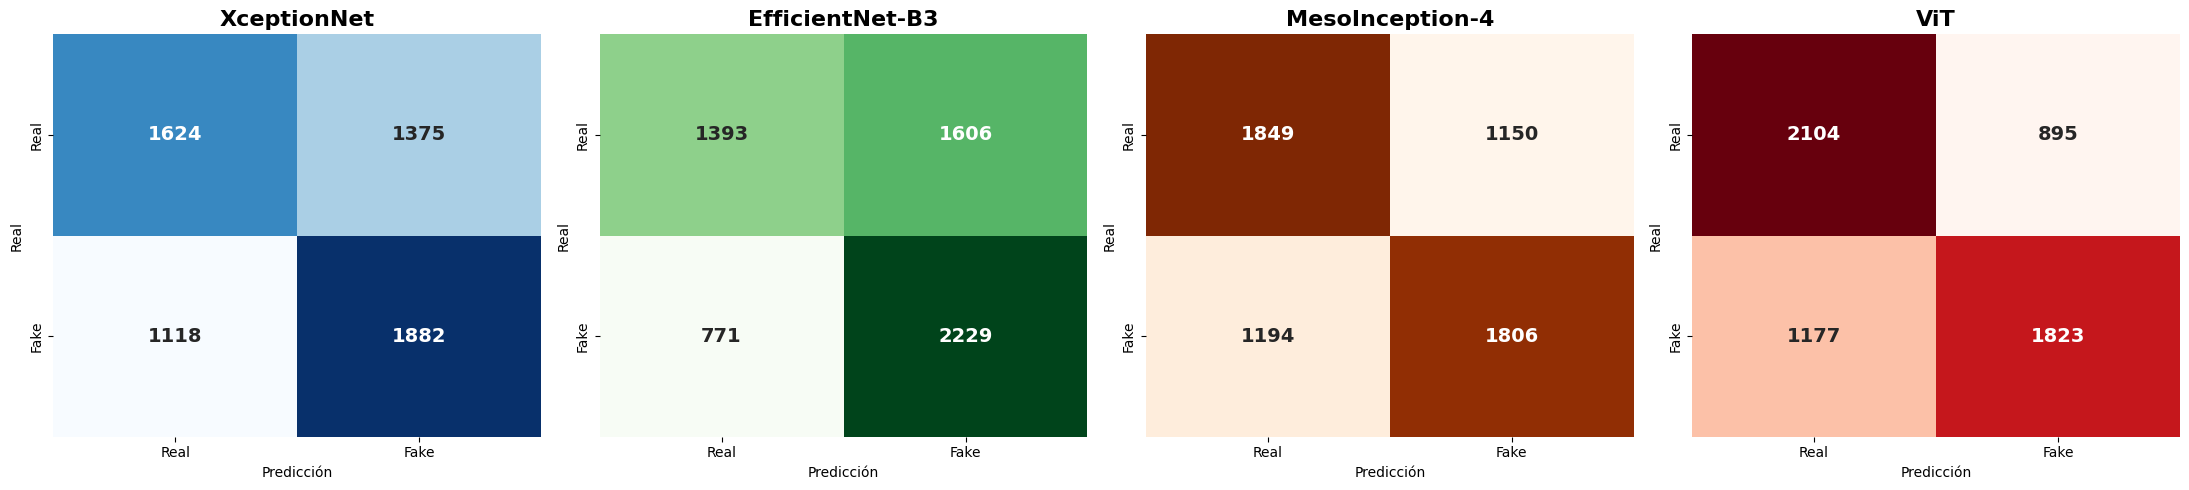

In [11]:
import os
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader

# 1. Asegúrate de tener el diccionario de transformaciones definido
transforms_dict = {
    "XceptionNet": transforms.Compose([
        transforms.Resize((299, 299)), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "EfficientNet-B3": transforms.Compose([
        transforms.Resize((300, 300)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "MesoInception-4": transforms.Compose([
        transforms.Resize((256, 256)), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "ViT": transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
}

# 2. Diccionario para guardar las matrices reales
resultados_matrices = {}

# 3. BUCLE ÚNICO Y SEGURO
for nombre, path in MODEL_PATHS.items():
    print(f"\n🚀 Evaluando {nombre}...")
    
    try:
        # A. Cargar Arquitectura específica según el nombre
        if nombre == "XceptionNet":
            model_eval = timm.create_model('xception', pretrained=False, num_classes=2)
        elif nombre == "EfficientNet-B3":
            model_eval = timm.create_model('tf_efficientnet_b3', pretrained=False, num_classes=2)
        elif nombre == "MesoInception-4":
            model_eval = MesoInception4(num_classes=2)
        elif nombre == "ViT":
            model_eval = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)

        # B. Cargar Pesos
        model_eval.load_state_dict(torch.load(path, map_location=DEVICE))
        model_eval.to(DEVICE)
        model_eval.eval()

        # C. Crear Loader específico con el tamaño de imagen correcto para ESTE modelo
        dataset_eval = DeepfakeDatasetC40(PATH_C40, transform=transforms_dict[nombre])
        loader_eval = DataLoader(dataset_eval, batch_size=32, shuffle=False)

        # D. Inferencia
        y_true_list, y_prob_list = [], []
        with torch.no_grad():
            for inputs, labels in tqdm(loader_eval, desc=f"🔍 {nombre}"):
                inputs = inputs.to(DEVICE)
                outputs = model_eval(inputs)
                probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                y_prob_list.extend(probs)
                y_true_list.extend(labels.numpy())

        # E. Calcular y Guardar Matriz
        y_pred_final = (np.array(y_prob_list) > 0.5).astype(int)
        resultados_matrices[nombre] = confusion_matrix(y_true_list, y_pred_final)
        print(f"✅ Matriz de {nombre} generada correctamente.")

    except Exception as e:
        print(f"❌ Error evaluando {nombre}: {e}")

# ==========================================
# 4. DIBUJAR LAS 4 MATRICES (Ahora serán diferentes)
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
cmaps = ['Blues', 'Greens', 'Oranges', 'Reds']

for i, (nombre, matrix) in enumerate(resultados_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', ax=axes[i], cmap=cmaps[i], cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(nombre, fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')
    axes[i].set_xticklabels(['Real', 'Fake'])
    axes[i].set_yticklabels(['Real', 'Fake'])

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# TABLA COMPARATIVA C40 CON TODAS LAS COLUMNAS COLOREADAS
# ==========================================
import pandas as pd
import seaborn as sns

# 1. Preparación del DataFrame (Asegúrate de que df_resultados existe)
df_metricas = pd.DataFrame(resultados).copy()

# Opcional: Convertir parámetros a Millones para mejor lectura
if 'Params' in df_metricas.columns:
    df_metricas['Params'] = df_metricas['Params'] / 1_000_000

df_metricas.set_index("Modelo", inplace=True)

# 2. Definición de paletas
cm_good = sns.light_palette("seagreen", as_cmap=True)  # 🟢 Más alto = mejor
cm_bad = sns.light_palette("indianred", as_cmap=True)  # 🔴 Más bajo = mejor (Rojo oscuro es peor valor)

# 3. Aplicar estilo a TODAS las columnas
display(df_metricas.style
    # Coloreamos las métricas de rendimiento (Verde) - AÑADIDAS Prec, Rec y F1
    .background_gradient(cmap=cm_good, subset=['Acc', 'Prec', 'Rec', 'F1', 'AUC', 'MCC'])
    
    # Coloreamos las métricas de error y coste (Rojo)
    .background_gradient(cmap=cm_bad, subset=['Loss', 'Time_ms', 'Params'])
    
    # Formato de 4 decimales
    .format("{:.4f}")
    # Formato especial para parámetros (2 decimales y sufijo M)
    .format("{:.2f}M", subset=['Params'])
)

,Acc,Prec,Rec,F1,AUC,Loss,MCC,Time_ms,Params
Modelo,,,,,,,,,
XceptionNet,0.5844,0.5778,0.6273,0.6016,0.6209,0.9662,0.1695,8.0287,20.81M
EfficientNet-B3,0.6038,0.5812,0.7430,0.6522,0.6507,0.8187,0.2160,6.6191,10.70M
MesoInception-4,0.6093,0.6110,0.6020,0.6064,0.6621,0.6557,0.2186,3.4140,1.26M
ViT,0.6546,0.6707,0.6077,0.6376,0.7080,0.8099,0.3106,8.8127,85.80M
